In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import re
import unicodedata
import matplotlib.pyplot as plt

In [3]:
# hyperparameters
embed_size  = 128   # was 64
hidden_size = 256
dropout     = 0.1
batch_size  = 64
max_iters   = 20000  # was 5000 — needs more steps
eval_every  = 1000
lr          = 3e-4   # was 1e-3 — lower, more stable
max_len     = 10

# hyperparameters
#embed_size  = 64
#hidden_size = 256
n_layers    = 1
#dropout     = 0.1
#batch_size  = 64
#max_iters   = 5000
#eval_every  = 500
#lr          = 1e-3
#max_len     = 10   # max sentence length (words)
SOS         = 0    # start of sentence token index
EOS         = 1    # end of sentence token index
device      = 'cuda' if torch.cuda.is_available() else 'cpu'
# ------------

In [4]:
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def clean(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s.strip()

# load pairs
pairs = []
with open('spa-eng/spa.txt', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            eng = clean(parts[0])
            spa = clean(parts[1])
            if len(eng.split()) < max_len and len(spa.split()) < max_len:
                pairs.append((eng, spa))

random.shuffle(pairs)
pairs = pairs[:10000]
print(f"total pairs: {len(pairs)}")
print(f"sample: {pairs[0]}")

total pairs: 10000
sample: ('take some aspirin .', 'toma una aspirina .')


In [5]:
class Vocab:

    def __init__(self, name):
        self.name     = name
        self.word2idx = {'<SOS>': 0, '<EOS>': 1}
        self.idx2word = {0: '<SOS>', 1: '<EOS>'}
        self.n_words  = 2

    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1

src_vocab = Vocab('english')
tgt_vocab = Vocab('spanish')

for eng, spa in pairs:
    src_vocab.add_sentence(eng)
    tgt_vocab.add_sentence(spa)

print(f"english vocab: {src_vocab.n_words} words")
print(f"spanish vocab: {tgt_vocab.n_words} words")

english vocab: 4404 words
spanish vocab: 6911 words


In [6]:
def sentence_to_tensor(vocab, sentence):
    """ convert sentence string → tensor of indices, with EOS appended """
    indices = [vocab.word2idx[w] for w in sentence.split()]
    indices.append(EOS)
    return torch.tensor(indices, dtype=torch.long, device=device)

def get_pair_tensors(pair):
    src = sentence_to_tensor(src_vocab, pair[0])
    tgt = sentence_to_tensor(tgt_vocab, pair[1])
    return src, tgt

In [7]:
class Encoder(nn.Module):
    """ encodes source sentence into a sequence of hidden states """

    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.gru       = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        # x: (1, src_len)
        embedded = self.dropout(self.embedding(x))   # (1, src_len, embed_size)
        outputs, hidden = self.gru(embedded)          # outputs: (1, src_len, hidden)
                                                      # hidden:  (1, 1, hidden)
        return outputs, hidden

In [8]:
class Attention(nn.Module):
    """ Bahdanau (additive) attention — scores each encoder state given decoder state """

    def __init__(self, hidden_size):
        super().__init__()
        self.W1 = nn.Linear(hidden_size, hidden_size)  # project encoder outputs
        self.W2 = nn.Linear(hidden_size, hidden_size)  # project decoder hidden
        self.V  = nn.Linear(hidden_size, 1)            # score → scalar

    def forward(self, encoder_outputs, decoder_hidden):
        # encoder_outputs: (1, src_len, hidden)
        # decoder_hidden:  (1, 1, hidden)

        enc = self.W1(encoder_outputs)          # (1, src_len, hidden)
        dec = self.W2(decoder_hidden)           # (1, 1, hidden) → broadcasts over src_len
        scores = self.V(torch.tanh(enc + dec))  # (1, src_len, 1)

        weights = torch.softmax(scores, dim=1)              # (1, src_len, 1)
        context = (weights * encoder_outputs).sum(dim=1, keepdim=True)  # (1, 1, hidden)
        return context, weights

In [9]:
class Decoder(nn.Module):
    """ decodes one token at a time, attending over encoder outputs each step """

    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(hidden_size)
        self.gru       = nn.GRU(embed_size + hidden_size, hidden_size, batch_first=True)
        self.fc        = nn.Linear(hidden_size, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs):
        # input_token:     (1, 1)
        # hidden:          (1, 1, hidden)  ← (num_layers, batch, hidden)
        # encoder_outputs: (1, src_len, hidden)

        embedded = self.dropout(self.embedding(input_token))        # (1, 1, embed_size)
        context, weights = self.attention(encoder_outputs, hidden)  # (1, 1, hidden)

        gru_input     = torch.cat([embedded, context], dim=2)       # (1, 1, embed+hidden)
        output, h_new = self.gru(gru_input, hidden)                 # h_new: (1, 1, hidden)
        prediction    = self.fc(output.squeeze(1))                  # (1, vocab_size)

        return prediction, h_new, weights                           # h_new stays (1, 1, hidden)

In [10]:
class Seq2Seq(nn.Module):
    """ encoder-decoder translator with Bahdanau attention """

    def __init__(self):
        super().__init__()
        self.encoder = Encoder(src_vocab.n_words, embed_size, hidden_size)
        self.decoder = Decoder(tgt_vocab.n_words, embed_size, hidden_size)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        encoder_outputs, hidden = self.encoder(src)
        # hidden comes out of GRU as (1, 1, hidden) — don't unsqueeze again
        
        tgt_len   = tgt.shape[0]
        outputs   = torch.zeros(tgt_len, tgt_vocab.n_words).to(device)
        input_tok = torch.tensor([[SOS]], device=device)
    
        for t in range(tgt_len):
            pred, hidden, _ = self.decoder(input_tok, hidden, encoder_outputs)
            outputs[t]      = pred
    
            use_teacher = random.random() < teacher_forcing_ratio
            input_tok   = tgt[t].view(1, 1) if use_teacher else pred.argmax(1).unsqueeze(0)
    
        return outputs

model = Seq2Seq().to(device)
print(f"total params: {sum(p.numel() for p in model.parameters()):,}")

total params: 4,145,792


In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion = nn.CrossEntropyLoss(ignore_index=SOS)

train_pairs = pairs[:8000]
val_pairs   = pairs[8000:]

def train_step(pair):
    src, tgt = get_pair_tensors(pair)
    src = src.unsqueeze(0)
    optimizer.zero_grad()
    outputs = model(src, tgt)
    loss    = criterion(outputs, tgt)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(pairs, n=200):
    model.eval()
    total = 0
    for pair in random.sample(pairs, n):
        src, tgt = get_pair_tensors(pair)
        src      = src.unsqueeze(0)
        outputs  = model(src, tgt, teacher_forcing_ratio=0.0)
        total   += criterion(outputs, tgt).item()
    model.train()
    return total / n

# accumulate losses across runs
all_runs = []   # each entry is a list of per-step losses for one run

In [17]:
# --- run this cell multiple times to continue training ---
losses = []

for i in range(1, max_iters + 1):
    pair = random.choice(train_pairs)
    loss = train_step(pair)
    losses.append(loss)

    if i % eval_every == 0:
        val_loss = evaluate(val_pairs)
        scheduler.step(val_loss)
        print(f"step {i:5d}/{max_iters} | train {sum(losses[-eval_every:])/eval_every:.4f} | val {val_loss:.4f}")

all_runs.append(losses)
print(f"run {len(all_runs)} done")

step  1000/20000 | train 2.5472 | val 4.3396
step  2000/20000 | train 2.4329 | val 4.2960
step  3000/20000 | train 2.4521 | val 4.4130
step  4000/20000 | train 2.5172 | val 4.1913
step  5000/20000 | train 2.5438 | val 4.2813
step  6000/20000 | train 2.4654 | val 4.2608
step  7000/20000 | train 2.4480 | val 4.1545
step  8000/20000 | train 2.4300 | val 4.0704
step  9000/20000 | train 2.4443 | val 4.1364
step 10000/20000 | train 2.4105 | val 4.1432
step 11000/20000 | train 2.3931 | val 4.2652
step 12000/20000 | train 2.4119 | val 4.5250
step 13000/20000 | train 2.4366 | val 4.1279
step 14000/20000 | train 2.4920 | val 4.2428
step 15000/20000 | train 2.3687 | val 4.3790
step 16000/20000 | train 2.4171 | val 4.2723
step 17000/20000 | train 2.4294 | val 4.0280
step 18000/20000 | train 2.4172 | val 4.3987
step 19000/20000 | train 2.3325 | val 4.1259
step 20000/20000 | train 2.4186 | val 4.4798
run 3 done


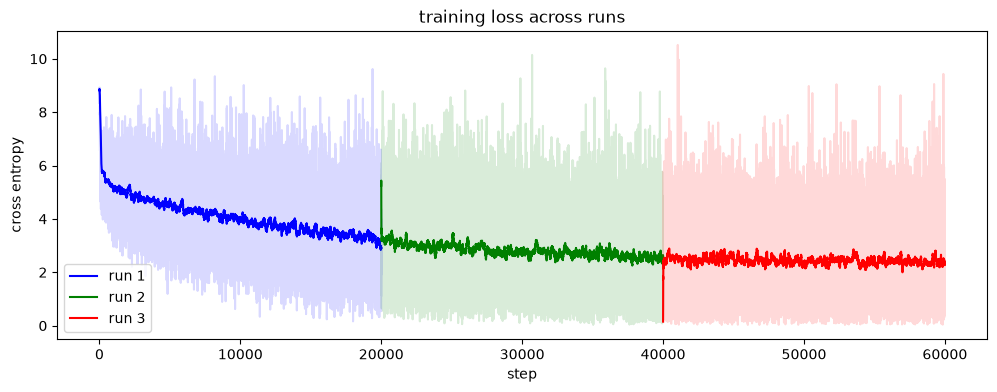

In [18]:
def smooth(losses, window=100):
    return [sum(losses[max(0,i-window):i+1]) / len(losses[max(0,i-window):i+1])
            for i in range(len(losses))]

plt.figure(figsize=(12, 4))
colors = ['blue', 'green', 'red']
offset = 0

for idx, run_losses in enumerate(all_runs):
    steps = range(offset, offset + len(run_losses))
    plt.plot(list(steps), run_losses, alpha=0.15, color=colors[idx])
    plt.plot(list(steps), smooth(run_losses), color=colors[idx], label=f'run {idx+1}')
    offset += len(run_losses)

plt.title("training loss across runs")
plt.xlabel("step")
plt.ylabel("cross entropy")
plt.legend()
plt.show()

In [19]:
@torch.no_grad()
def translate(sentence):
    model.eval()
    src    = sentence_to_tensor(src_vocab, clean(sentence)).unsqueeze(0)  # (1, src_len)
    encoder_outputs, hidden = model.encoder(src)
    # hidden comes out as (1, 1, hidden) — don't unsqueeze again

    input_tok = torch.tensor([[SOS]], device=device)
    result    = []

    for _ in range(max_len):
        pred, hidden, _ = model.decoder(input_tok, hidden, encoder_outputs)
        top1 = pred.argmax(1).item()
        if top1 == EOS:
            break
        result.append(tgt_vocab.idx2word[top1])
        input_tok = torch.tensor([[top1]], device=device)

    model.train()
    return ' '.join(result)

# testing
test_sentences = [
    "my name is  .",
    "where are you .",
    "tom is a good student ."
]
for s in test_sentences:
    print(f"  eng: {s}")
    print(f"  spanish: {translate(s)}\n")

  eng: my name is  .
  spanish: mi hermano es . .

  eng: where are you .
  spanish: donde estan estas .

  eng: tom is a good student .
  spanish: tom es un buen . .

